In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install lmfit
from lmfit.models import GaussianModel

In [3]:
log_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_log_mean raman')
sta_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_sta_mean raman')

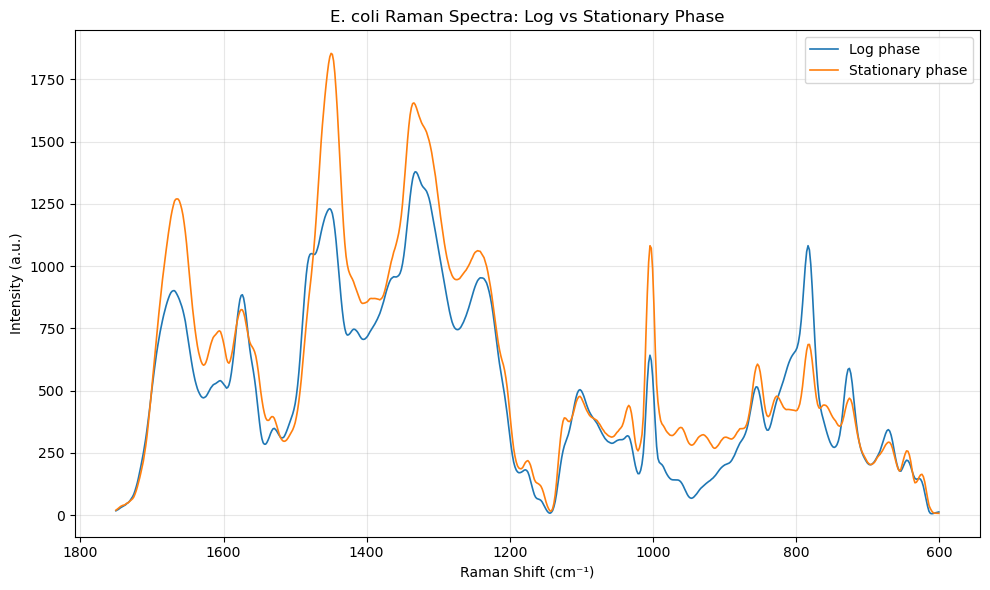

In [4]:
# Load each Raman spectrum from its sheet
log_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx",
                       sheet_name="ec_log_mean raman")

sta_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx",
                       sheet_name="ec_sta_mean raman")

# Standardise column names (first two columns are wavenumber + intensity)
log_df = log_df.iloc[:, :2]
sta_df = sta_df.iloc[:, :2]

log_df.columns = ["wavenumber", "intensity"]
sta_df.columns = ["wavenumber", "intensity"]

# Sort just in case
log_df = log_df.sort_values("wavenumber")
sta_df = sta_df.sort_values("wavenumber")

# Plot both on one graph
plt.figure(figsize=(10,6))
plt.plot(log_df["wavenumber"], log_df["intensity"], label="Log phase", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity"], label="Stationary phase", linewidth=1.2)

# Reverse x-axis (Raman convention)
plt.gca().invert_xaxis()

plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("E. coli Raman Spectra: Log vs Stationary Phase")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
x_log = log_df["wavenumber"].values
y_log = log_df["intensity"].values

# sampling step Δν
dnu_log = np.diff(x_log)
dnu_log_mean = np.mean(dnu_log)

fs_log = 1.0 / dnu_log_mean      # sampling "frequency" in 1/(cm⁻¹)
f_nyq_log = fs_log / 2.0         # Nyquist frequency
N_log = len(x_log)
max_params_log = N_log // 2      # upper bound on independent real parameters

print("LOG PHASE:")
print(f"  N points            = {N_log}")
print(f"  mean Δν             = {dnu_log_mean:.6f} cm⁻¹")
print(f"  Nyquist frequency   = {f_nyq_log:.6f} (1/cm)")
print(f"  Nyquist upper bound ≈ {max_params_log} independent real parameters\n")


LOG PHASE:
  N points            = 637
  mean Δν             = 1.808508 cm⁻¹
  Nyquist frequency   = 0.276471 (1/cm)
  Nyquist upper bound ≈ 318 independent real parameters



In [6]:
x_sta = sta_df["wavenumber"].values
y_sta = sta_df["intensity"].values

dnu_sta = np.diff(x_sta)
dnu_sta_mean = np.mean(dnu_sta)

fs_sta = 1.0 / dnu_sta_mean
f_nyq_sta = fs_sta / 2.0
N_sta = len(x_sta)
max_params_sta = N_sta // 2

print("STATIONARY PHASE:")
print(f"  N points            = {N_sta}")
print(f"  mean Δν             = {dnu_sta_mean:.6f} cm⁻¹")
print(f"  Nyquist frequency   = {f_nyq_sta:.6f} (1/cm)")
print(f"  Nyquist upper bound ≈ {max_params_sta} independent real parameters")

STATIONARY PHASE:
  N points            = 637
  mean Δν             = 1.808508 cm⁻¹
  Nyquist frequency   = 0.276471 (1/cm)
  Nyquist upper bound ≈ 318 independent real parameters


In [7]:
# Transforming data into reciprocal space using fourier transform
Y_log = np.fft.rfft(y_log)
freqs_log = np.fft.rfftfreq(N_log, d=dnu_log_mean)
print("LOG PHASE: number of non-negative frequency bins =", len(freqs_log))
print("Max frequency from FFT (should be ~Nyquist):", freqs_log[-1])

LOG PHASE: number of non-negative frequency bins = 319
Max frequency from FFT (should be ~Nyquist): 0.2760370074009793


## Now we normalise so that the peak fitting is numerically stable

In [8]:
# Normalise intensities so max = 1
log_df["intensity_norm"] = log_df["intensity"] / log_df["intensity"].max()
sta_df["intensity_norm"] = sta_df["intensity"] / sta_df["intensity"].max()

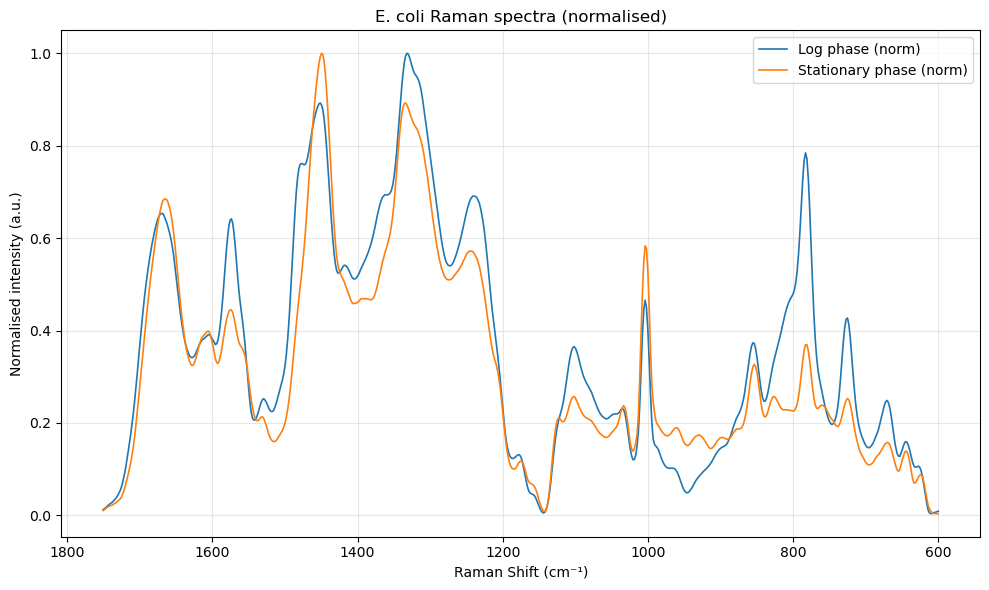

In [9]:
# Plotting with normalised data

plt.figure(figsize=(10, 6))
plt.plot(log_df["wavenumber"], log_df["intensity_norm"], label="Log phase (norm)", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity_norm"], label="Stationary phase (norm)", linewidth=1.2)

plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Normalised intensity (a.u.)")
plt.title("E. coli Raman spectra (normalised)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# The peaks are noticeably more defined now, especially for the log phase data.

In [10]:
x = log_df["wavenumber"].values
y = log_df["intensity_norm"].values

Detected peaks: 20
Settings used:
  window: 600-1800 cm^-1
  baseline: AsLS (lam=1e+05, p=0.005)  | used_for_detection=True
  smoothing: True (sg_window=11, sg_poly=3)
  min_sep_cm1=1.0 -> distance_pts=1 (dx≈1.805 cm^-1)
  height_frac=0.0001 -> height=6.62e-05
  prom_frac=0.0005 -> prominence=0.000331


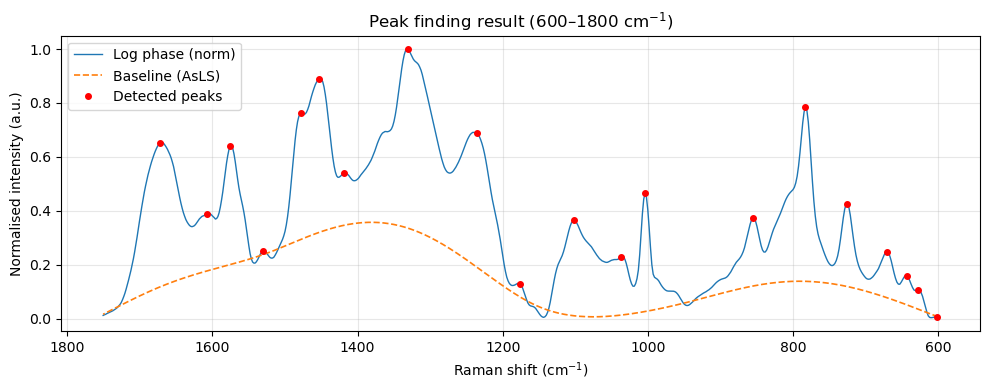


Top 20 peaks by prominence:
 1.  1330.42 cm^-1   prominence=0.6654
 2.   783.08 cm^-1   prominence=0.6346
 3.  1671.93 cm^-1   prominence=0.5338
 4.  1004.02 cm^-1   prominence=0.4194
 5.  1453.18 cm^-1   prominence=0.4124
 6.  1575.41 cm^-1   prominence=0.2556
 7.  1101.78 cm^-1   prominence=0.2544
 8.   725.26 cm^-1   prominence=0.2337
 9.  1235.95 cm^-1   prominence=0.2188
10.   855.63 cm^-1   prominence=0.1281
11.   670.85 cm^-1   prominence=0.1204
12.   643.48 cm^-1   prominence=0.0345
13.  1607.74 cm^-1   prominence=0.0262
14.  1176.45 cm^-1   prominence=0.0242
15.  1037.38 cm^-1   prominence=0.0144
16.  1530.91 cm^-1   prominence=0.0109
17.  1418.34 cm^-1   prominence=0.0102
18.  1477.46 cm^-1   prominence=0.0044
19.   602.21 cm^-1   prominence=0.0024
20.   627.79 cm^-1   prominence=0.0005


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve

def baseline_asls(y, lam=1e6, p=0.01, niter=10):
    """Asymmetric least-squares baseline estimate."""
    y = np.asarray(y)
    L = y.size
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.T)
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

# =============================
# EASY-TO-ADJUST SETTINGS
# =============================
xmin, xmax = 600, 1800          # analysis window

use_smoothing = True
sg_window = 11                  # must be odd; 11/15/21...
sg_poly   = 3

# "Strict" = reject noise bumps; if you want *more* small bumps, lower prom/height
min_sep_cm1  = 1.0              # strict separation (cm^-1)
height_frac  = 0.0001           # strict height floor (fraction of max)
prom_frac    = 0.0005           # strict prominence (fraction of max)

# Baseline fit (shown on plot; used for detection signal only)
use_baseline_for_detection = True
lam = 1e5                        # increase -> straighter baseline; decrease -> more curved
p   = 0.005                      # smaller -> baseline sits more under peaks

# =============================
# 1) Window the spectrum
# =============================
mask = (x >= xmin) & (x <= xmax)
x_use = x[mask]
y_use = y[mask]

# Ensure x increases for robust distance conversion
if x_use[0] > x_use[-1]:
    orderx = np.argsort(x_use)
    x_use = x_use[orderx]
    y_use = y_use[orderx]

# =============================
# 2) Baseline fit (not subtracted in plot)
# =============================
base = baseline_asls(y_use, lam=lam, p=p, niter=10)

# =============================
# 3) Detection signal (baseline-detrended, optional smoothing)
# =============================
y_det = (y_use - base) if use_baseline_for_detection else y_use
y_det = np.clip(y_det, 0, None)

if use_smoothing and len(y_det) >= sg_window:
    w = sg_window if sg_window % 2 == 1 else sg_window + 1
    w = min(w, len(y_det) if len(y_det) % 2 == 1 else len(y_det) - 1)
    y_det = savgol_filter(y_det, window_length=w, polyorder=min(sg_poly, w-2))

# =============================
# 4) Convert min separation (cm^-1) -> points
# =============================
dx = float(np.median(np.diff(x_use)))
distance_pts = int(np.ceil(min_sep_cm1 / dx))

# =============================
# 5) Peak finding (scaled thresholds)
# =============================
ymax = float(np.max(y_det))
height = height_frac * ymax
prominence = prom_frac * ymax

peaks, props = find_peaks(
    y_det,
    height=height,
    prominence=prominence,
    distance=distance_pts
)

peak_pos  = x_use[peaks]
peak_y    = y_use[peaks]               # markers on original spectrum
peak_prom = props["prominences"]

print(f"Detected peaks: {len(peaks)}")
print("Settings used:")
print(f"  window: {xmin}-{xmax} cm^-1")
print(f"  baseline: AsLS (lam={lam:.2g}, p={p})  | used_for_detection={use_baseline_for_detection}")
print(f"  smoothing: {use_smoothing} (sg_window={sg_window}, sg_poly={sg_poly})")
print(f"  min_sep_cm1={min_sep_cm1} -> distance_pts={distance_pts} (dx≈{dx:.3f} cm^-1)")
print(f"  height_frac={height_frac} -> height={height:.3g}")
print(f"  prom_frac={prom_frac} -> prominence={prominence:.3g}")

# =============================
# 6) Plot (spectrum + baseline + peaks)
# =============================
plt.figure(figsize=(10, 4))
plt.plot(x_use, y_use, linewidth=1, label="Log phase (norm)")
plt.plot(x_use, base, "--", linewidth=1.2, label="Baseline (AsLS)")
plt.plot(peak_pos, peak_y, "ro", markersize=4, label="Detected peaks")
plt.gca().invert_xaxis()
plt.xlabel("Raman shift (cm$^{-1}$)")
plt.ylabel("Normalised intensity (a.u.)")
plt.title("Peak finding result (600–1800 cm$^{-1}$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =============================
# 7) Sort peaks by prominence (for initial centres later)
# =============================
order = np.argsort(peak_prom)[::-1]
peak_pos_sorted  = peak_pos[order]
peak_prom_sorted = peak_prom[order]
peak_y_sorted    = peak_y[order]

top_n = min(20, len(peak_pos_sorted))
print(f"\nTop {top_n} peaks by prominence:")
for i in range(top_n):
    print(f"{i+1:>2}. {peak_pos_sorted[i]:8.2f} cm^-1   prominence={peak_prom_sorted[i]:.4f}")


# Fitting and BFI

## improved version

Forward selection (forced full curve, AREA NORMALIZATION)
n=637, baseline_deg=2, sigma,gamma=(6.0,6.0), min_sep=15.0
Priors: Δb=4.0, ΔA=35.0, amps>=0

step  center(cm^-1)   k  rank  cond(X)        RSS         s^2        lnBFI       ΔlnBFI
----------------------------------------------------------------------------------------
   0    (baseline)   3     3   3.76e+00   3.070e+01  4.842e-02     48.1324          -
   1       1330.42   4     4   2.60e+02   2.514e+01  3.971e-02    109.4984    61.3660
   2       1453.18   5     5   2.67e+02   2.153e+01  3.407e-02    156.4554    46.9570
   3        783.08   6     6   2.73e+02   1.832e+01  2.903e-02    205.4700    49.0146


C:\Users\harsa\AppData\Local\Temp\ipykernel_10500\814191507.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(v, x)  # Integrate using trapezoidal rule


   4       1235.95   7     7   2.80e+02   1.673e+01  2.656e-02    231.8489    26.3789
   5       1671.93   8     8   2.84e+02   1.553e+01  2.469e-02    253.2240    21.3751
   6       1477.46   9     9   2.99e+02   1.445e+01  2.300e-02    273.6964    20.4724
   7       1575.41  10    10   3.02e+02   1.360e+01  2.170e-02    290.3113    16.6149
   8        725.26  11    11   3.03e+02   1.301e+01  2.079e-02    302.0187    11.7074
   9       1418.34  12    12   3.13e+02   1.246e+01  1.994e-02    313.2049    11.1862
  10        670.85  13    13   3.32e+02   1.219e+01  1.953e-02    317.9716     4.7667
  11        855.63  14    14   3.43e+02   1.189e+01  1.909e-02    323.3952     5.4236
  12        643.48  15    15   3.80e+02   1.170e+01  1.881e-02    326.3167     2.9215
  13        627.79  16    16   4.29e+02   1.161e+01  1.869e-02    326.6304     0.3137
  14       1607.74  17    17   4.29e+02   1.155e+01  1.862e-02    325.9123    -0.7181
  15        602.21  18    18   4.52e+02   1.150e+01  1

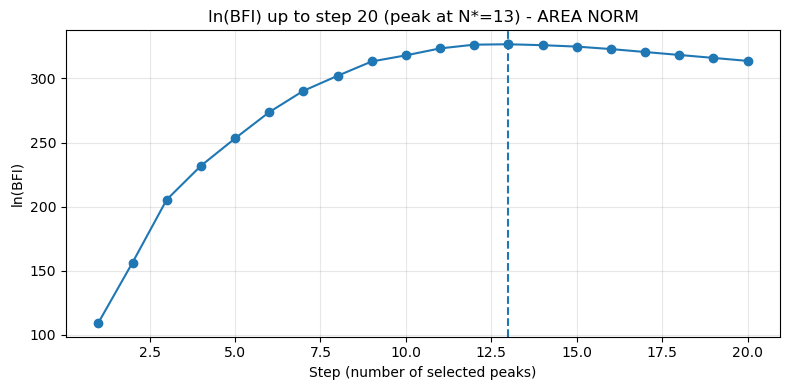

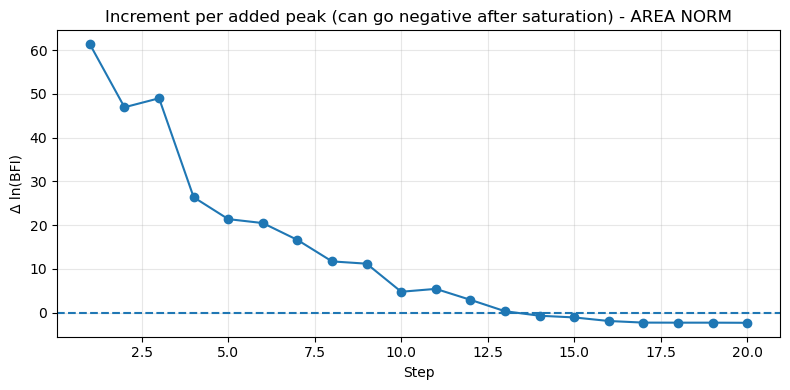

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import voigt_profile
from scipy.optimize import lsq_linear

# ===========================
# SETTINGS
# ===========================
sigma_fixed = 6.0
gamma_fixed = 6.0
baseline_deg = 2

min_sep_fit_cm1 = 15.0

Amax = 35.0  # CHANGED: Increased for area normalization (was 2.0)
bmax = 2.0

max_steps = 20          # force plotting up to this many peaks
force_full_curve = True # <-- key: keep going even if ΔlnBFI < 0

# ===========================
x_use = np.asarray(x_use, float)
y_use = np.asarray(y_use, float)
cands = np.asarray(peak_pos_sorted, float)

if x_use[0] > x_use[-1]:
    o = np.argsort(x_use)
    x_use, y_use = x_use[o], y_use[o]

n = len(x_use)
n_base = baseline_deg + 1

def x_scaled(x):
    return 2*(x - x.min())/(x.max() - x.min()) - 1.0

def make_voigt_col(x, center, sigma, gamma):
    # CHANGED: Area normalization instead of peak-height
    v = voigt_profile(x - center, sigma, gamma)
    area = np.trapz(v, x)  # Integrate using trapezoidal rule
    return v / area if (area > 0 and np.isfinite(area)) else np.zeros_like(x)

def build_X(x, centers, deg, sigma, gamma):
    xs = x_scaled(x)
    B = np.vstack([xs**i for i in range(deg+1)]).T
    V = np.vstack([make_voigt_col(x, c, sigma, gamma) for c in centers]).T if len(centers) else np.zeros((len(x),0))
    return np.hstack([B, V])

def fit_nonneg_amps(X, y, n_base):
    k = X.shape[1]
    lb = np.full(k, -np.inf)
    ub = np.full(k,  np.inf)
    lb[n_base:] = 0.0  # amplitudes >= 0

    res = lsq_linear(X, y, bounds=(lb, ub), lsmr_tol='auto', verbose=0)
    beta = res.x
    yhat = X @ beta
    r = y - yhat
    RSS = float(np.sum(r**2))

    dof = max(n - k, 1)
    s2 = RSS / dof

    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(XtX)

    cov = s2 * XtX_inv
    condX = float(np.linalg.cond(X))
    rank = np.linalg.matrix_rank(X)
    return beta, yhat, RSS, s2, cov, rank, condX

def ln_bfi(s2, cov, prior_widths, n, k):
    """
    Correct Laplace ln(BFI) consistent with:
      BFI ≈ (2π)^(k/2) * L_max * sqrt(det(Cov)) / ∏Δθ
    using plug-in s^2 = RSS/(n-k).

    L_max (with σ^2 replaced by s^2):
      ln L_max = -(n/2)ln(2π) - (n/2)ln(s^2) - (n-k)/2
    """
    dof = n - k
    if dof <= 0 or s2 <= 0 or not np.isfinite(s2):
        return np.nan

    sign, logdet = np.linalg.slogdet(cov)
    if sign != 1 or not np.isfinite(logdet):
        return np.nan

    ll = (-0.5 * n * np.log(2*np.pi)
          -0.5 * n * np.log(s2)
          -0.5 * dof)

    occam = (0.5 * k * np.log(2*np.pi)
             +0.5 * logdet)

    prior = -np.sum(np.log(prior_widths))

    return float(ll + occam + prior)

def can_add(existing, cand, min_sep):
    return all(abs(cand - e) >= min_sep for e in existing)

# ---------- baseline-only start ----------
selected = []
history = []

X0 = build_X(x_use, [], baseline_deg, sigma_fixed, gamma_fixed)
beta0, yhat0, RSS0, s20, cov0, rank0, cond0 = fit_nonneg_amps(X0, y_use, n_base)
prior0 = np.array([2*bmax]*n_base, float)

k0 = X0.shape[1]
lnB0 = ln_bfi(s20, cov0, prior0, n=n, k=k0)

prev_lnB = lnB0

print("Forward selection (forced full curve, AREA NORMALIZATION)" if force_full_curve else "Forward selection (stops at saturation, AREA NORMALIZATION)")
print(f"n={n}, baseline_deg={baseline_deg}, sigma,gamma=({sigma_fixed},{gamma_fixed}), min_sep={min_sep_fit_cm1}")
print(f"Priors: Δb={2*bmax}, ΔA={Amax}, amps>=0")
print("")
print("step  center(cm^-1)   k  rank  cond(X)        RSS         s^2        lnBFI       ΔlnBFI")
print("----------------------------------------------------------------------------------------")
print(f"{0:>4d}  {'(baseline)':>12s}  {X0.shape[1]:>2d}  {rank0:>4d}  {cond0:>9.2e}  {RSS0:>10.3e}  {s20:>9.3e}  {lnB0:>10.4f}  {'-':>9s}")

for step in range(1, min(max_steps, len(cands)) + 1):
    best = None

    for c in cands:
        if c in selected:
            continue
        if not can_add(selected, float(c), min_sep_fit_cm1):
            continue

        centers_try = selected + [float(c)]
        X = build_X(x_use, centers_try, baseline_deg, sigma_fixed, gamma_fixed)
        beta, yhat, RSS, s2, cov, rank, condX = fit_nonneg_amps(X, y_use, n_base)

        prior = np.array([2*bmax]*n_base + [Amax]*len(centers_try), float)

        lnB = ln_bfi(s2, cov, prior, n=n, k=X.shape[1])
        if not np.isfinite(lnB):
            continue

        dlnB = lnB - prev_lnB
        if (best is None) or (dlnB > best[1]):
            best = (lnB, dlnB, float(c), X.shape[1], rank, condX, RSS, s2, yhat)

    if best is None:
        print("\nNo remaining candidates satisfy min_sep. Stopping.")
        break

    lnB, dlnB, c_best, k_best, rank_best, cond_best, RSS_best, s2_best, yhat_best = best
    selected.append(c_best)
    history.append((step, c_best, lnB, dlnB, k_best, rank_best, cond_best, RSS_best, s2_best, yhat_best))

    print(f"{step:>4d}  {c_best:>12.2f}  {k_best:>2d}  {rank_best:>4d}  {cond_best:>9.2e}  {RSS_best:>10.3e}  {s2_best:>9.3e}  {lnB:>10.4f}  {dlnB:>9.4f}")

    prev_lnB = lnB

# ---- arrays for plotting
steps = np.array([h[0] for h in history], int)
lnBFI_arr = np.array([h[2] for h in history], float)
dln_arr = np.array([h[3] for h in history], float)

# argmax peak (this is N*)
best_idx = int(np.nanargmax(lnBFI_arr))
N_star = int(steps[best_idx])
ln_star = float(lnBFI_arr[best_idx])

print("\nArgmax along curve:")
print(f"  N* = {N_star} at lnBFI = {ln_star:.4f}")

# plots
plt.figure(figsize=(8,4))
plt.plot(steps, lnBFI_arr, marker="o")
plt.axvline(N_star, linestyle="--")
plt.scatter([N_star], [ln_star], zorder=5)
plt.xlabel("Step (number of selected peaks)")
plt.ylabel("ln(BFI)")
plt.title(f"ln(BFI) up to step {steps.max()} (peak at N*={N_star}) - AREA NORM")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(steps, dln_arr, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Δ ln(BFI)")
plt.title("Increment per added peak (can go negative after saturation) - AREA NORM")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(f"Optimal number of peaks: N* = {N_star}")
print(f"Maximum ln(BFI): {ln_star:.2f}")
print(f"Fixed parameters: σ = γ = {sigma_fixed} cm⁻¹")
print(f"Minimum peak separation: {min_sep_fit_cm1} cm⁻¹")
print(f"Data points: n = {n}")
print(f"Baseline degree: {baseline_deg}")
print(f"\nModel at N* = {N_star}:")
print(f"  Total parameters: k = {n_base + N_star}")
print(f"  Baseline parameters: {n_base}")
print(f"  Peak amplitudes: {N_star}")
print(f"  RSS: {RSS_best:.4f}")
print(f"  s² = RSS/(n-k): {s2_best:.6f}")
print(f"  Condition number: {cond_best:.2e}")


FINAL RESULTS SUMMARY
Optimal number of peaks: N* = 13
Maximum ln(BFI): 326.63
Fixed parameters: σ = γ = 6.0 cm⁻¹
Minimum peak separation: 15.0 cm⁻¹
Data points: n = 637
Baseline degree: 2

Model at N* = 13:
  Total parameters: k = 16
  Baseline parameters: 3
  Peak amplitudes: 13
  RSS: 11.4799
  s² = RSS/(n-k): 0.018697
  Condition number: 4.65e+02


## Number of parameters for log data = 16

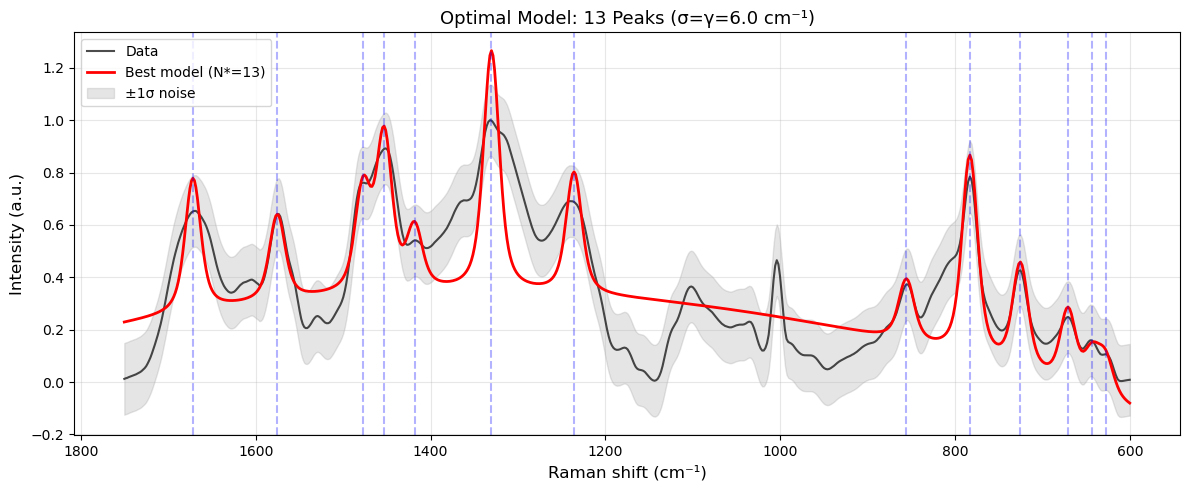

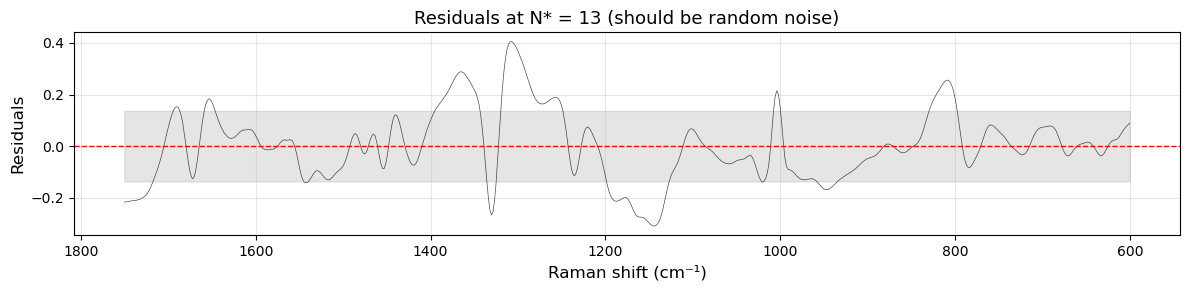

In [48]:
# Get the best model
best_history = history[best_idx]
yhat_best = best_history[9]

plt.figure(figsize=(12, 5))
plt.plot(x_use, y_use, 'k-', linewidth=1.5, label='Data', alpha=0.7)
plt.plot(x_use, yhat_best, 'r-', linewidth=2, label=f'Best model (N*={N_star})')
plt.fill_between(x_use, y_use - np.sqrt(s2_best), y_use + np.sqrt(s2_best), 
                 alpha=0.2, color='gray', label=r'±1σ noise')

# Mark peak positions
for i, c in enumerate(selected[:N_star]):
    plt.axvline(c, color='blue', linestyle='--', alpha=0.3)
    
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title(f'Optimal Model: {N_star} Peaks (σ=γ={sigma_fixed} cm⁻¹)', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals plot
residuals = y_use - yhat_best
plt.figure(figsize=(12, 3))
plt.plot(x_use, residuals, 'k-', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.fill_between(x_use, -np.sqrt(s2_best), +np.sqrt(s2_best), 
                 alpha=0.2, color='gray')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Residuals at N* = {N_star} (should be random noise)', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Amplitude analysis

C:\Users\harsa\AppData\Local\Temp\ipykernel_10500\814191507.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(v, x)  # Integrate using trapezoidal rule



AMPLITUDE ANALYSIS AT OPTIMAL MODEL (N* = 13)

Baseline coefficients (b0, b1, b2):
  b0 =   0.3185
  b1 =   0.1625
  b2 =  -0.2579

Peak amplitudes:
  Number of peaks: 13
  Min amplitude:     3.7361
  Max amplitude:    26.0788
  Mean amplitude:   11.7040
  Median amplitude: 10.8962

Prior settings:
  Baseline prior width (Δb): 4.0
  Amplitude prior width (ΔA): 35.0

Prior coverage check:
  ✓ All amplitudes within prior range [0, 35.0]

Detailed peak information:
 Peak     Center    Amplitude   % of Max
----------------------------------------
    1    1330.42      26.0788     100.0%
    2    1453.18      16.6234      63.7%
    3     783.08      21.7979      83.6%
    4    1235.95      13.2037      50.6%
    5    1671.93      14.2140      54.5%
    6    1477.46      10.8962      41.8%
    7    1575.41       9.2366      35.4%
    8     725.26      11.4147      43.8%
    9    1418.34       6.5510      25.1%
   10     670.85       7.8764      30.2%
   11     855.63       6.7110      25.7%

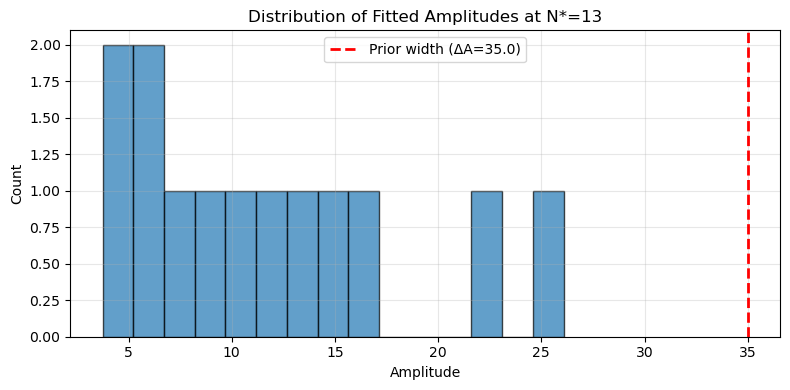

In [49]:
# ===========================
# AMPLITUDE ANALYSIS
# ===========================

# Get the best model (at N*)
best_step_idx = best_idx  # This is already calculated as argmax of lnBFI_arr
best_step_num = N_star

# Reconstruct the best model to get fitted parameters
centers_best = selected[:best_step_num]
X_best = build_X(x_use, centers_best, baseline_deg, sigma_fixed, gamma_fixed)
beta_best, yhat_best, RSS_best, s2_best, cov_best, rank_best, cond_best = fit_nonneg_amps(X_best, y_use, n_base)

# Extract amplitudes (skip first n_base coefficients which are baseline)
amplitudes = beta_best[n_base:]
baseline_coeffs = beta_best[:n_base]

print("\n" + "="*80)
print("AMPLITUDE ANALYSIS AT OPTIMAL MODEL (N* = {})".format(N_star))
print("="*80)

print(f"\nBaseline coefficients (b0, b1, b2):")
for i, b in enumerate(baseline_coeffs):
    print(f"  b{i} = {b:>8.4f}")

print(f"\nPeak amplitudes:")
print(f"  Number of peaks: {len(amplitudes)}")
print(f"  Min amplitude:   {amplitudes.min():>8.4f}")
print(f"  Max amplitude:   {amplitudes.max():>8.4f}")
print(f"  Mean amplitude:  {amplitudes.mean():>8.4f}")
print(f"  Median amplitude:{np.median(amplitudes):>8.4f}")

print(f"\nPrior settings:")
print(f"  Baseline prior width (Δb): {2*bmax}")
print(f"  Amplitude prior width (ΔA): {Amax}")

print(f"\nPrior coverage check:")
if amplitudes.max() < Amax:
    print(f"  ✓ All amplitudes within prior range [0, {Amax}]")
else:
    print(f"  ⚠ WARNING: Max amplitude ({amplitudes.max():.2f}) exceeds prior ({Amax})")
    print(f"    Consider increasing Amax to {amplitudes.max() * 1.5:.1f}")

if amplitudes.max() < 0.5 * Amax:
    print(f"  ⚠ Note: Max amplitude only {amplitudes.max()/Amax*100:.1f}% of prior width")
    print(f"    Consider decreasing Amax to {amplitudes.max() * 2.5:.1f} for tighter prior")

print(f"\nDetailed peak information:")
print(f"{'Peak':>5s} {'Center':>10s} {'Amplitude':>12s} {'% of Max':>10s}")
print("-" * 40)
for i, (center, amp) in enumerate(zip(centers_best, amplitudes), 1):
    pct = amp / amplitudes.max() * 100
    print(f"{i:>5d} {center:>10.2f} {amp:>12.4f} {pct:>9.1f}%")

# Histogram of amplitudes
plt.figure(figsize=(8, 4))
plt.hist(amplitudes, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(Amax, color='red', linestyle='--', linewidth=2, label=f'Prior width (ΔA={Amax})')
plt.xlabel('Amplitude')
plt.ylabel('Count')
plt.title(f'Distribution of Fitted Amplitudes at N*={N_star}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)

##  Calculating the prior max amplitude (35)

In [45]:
# Add this diagnostic code:
print("\n" + "="*80)
print("DIAGNOSTIC: Understanding amplitude scale")
print("="*80)

# Check what area-normalized voigt actually gives
test_center = 1330.42  # Your strongest peak
test_voigt = make_voigt_col(x_use, test_center, sigma_fixed, gamma_fixed)

print(f"\nTest Voigt at {test_center} cm⁻¹:")
print(f"  Peak height (in normalized space): {np.max(test_voigt):.6f}")
print(f"  Integral: ∫V(x)dx = {np.trapz(test_voigt, x_use):.6f}")
print(f"  Should be: 1.0 (by definition)")

# What amplitude would reproduce a peak of height 0.5 in your spectrum?
# If y ≈ A × V(x) and max(V) ≈ peak_height, then A ≈ y_height / V_height
peak_region = (x_use > test_center - 20) & (x_use < test_center + 20)
y_peak_height = np.max(y_use[peak_region])
V_peak_height = np.max(test_voigt)

A_expected = y_peak_height / V_peak_height
print(f"\nTo match observed peak height {y_peak_height:.4f}:")
print(f"  V peak height: {V_peak_height:.6f}")
print(f"  Expected amplitude: A ≈ {A_expected:.1f}")

print(f"\nActual fitted amplitude at this peak: 26.08")
print(f"Ratio (fitted/expected): {26.08/A_expected:.2f}x")

# Calculate principled prior from V_max
print(f"\n" + "="*80)
print("PRINCIPLED PRIOR CALCULATION:")
print("="*80)
print(f"\nFor area-normalized Voigt with σ=γ=6 cm⁻¹:")
print(f"  max(V) = {V_peak_height:.6f}")
print(f"\nTo fit peaks with heights h ∈ [0, 1]:")
print(f"  Required amplitudes: A = h / {V_peak_height:.6f}")
print(f"  For h = 0.1: A = {0.1/V_peak_height:.1f}")
print(f"  For h = 0.5: A = {0.5/V_peak_height:.1f}")
print(f"  For h = 1.0: A = {1.0/V_peak_height:.1f}")
print(f"\nConservative prior (1.2× max possible):")
Amax_principled = 1.2 / V_peak_height
print(f"  ΔA = {Amax_principled:.1f}")

print("="*80)


DIAGNOSTIC: Understanding amplitude scale

Test Voigt at 1330.42 cm⁻¹:
  Peak height (in normalized space): 0.035036
  Integral: ∫V(x)dx = 1.000000
  Should be: 1.0 (by definition)

To match observed peak height 1.0000:
  V peak height: 0.035036
  Expected amplitude: A ≈ 28.5

Actual fitted amplitude at this peak: 26.08
Ratio (fitted/expected): 0.91x

PRINCIPLED PRIOR CALCULATION:

For area-normalized Voigt with σ=γ=6 cm⁻¹:
  max(V) = 0.035036

To fit peaks with heights h ∈ [0, 1]:
  Required amplitudes: A = h / 0.035036
  For h = 0.1: A = 2.9
  For h = 0.5: A = 14.3
  For h = 1.0: A = 28.5

Conservative prior (1.2× max possible):
  ΔA = 34.3


C:\Users\harsa\AppData\Local\Temp\ipykernel_10500\558751904.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(v, x)  # Integrate using trapezoidal rule
C:\Users\harsa\AppData\Local\Temp\ipykernel_10500\1104925543.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Integral: ∫V(x)dx = {np.trapz(test_voigt, x_use):.6f}")
